**Instructions:**
- Installation FenicsX 0.10: if using Linux or Mac with conda (simplest way) do: conda create -n fenicsx-env;
conda activate fenicsx-env; conda install -c conda-forge fenics-dolfinx mpich pyvista scipy python-gmsh matplotlib scikit-learn;
- Installation Windows: set WSL (follow the tutorial https://www.youtube.com/watch?v=_qb2J0_OZok), and then as in Linux.
- Sections FenicsX-independent : 0, 4.2, 5, 6, 7, 8, 10 
- Sections FenicsX-dependent : 1, 2, 3, 4.1, 9
- Intrusive and non-intrusive are both in : https://github.com/felipefr/ddfenics . 
- Main classes : DDMaterial, DDMetric, DDSearch, DDSolver, DDProblem

0) Imports (non - Fenicsx)

In [1]:
import pyvista as pv # Plotting
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors
from timeit import default_timer as timer 

1) Imports (Fenicsx)

In [2]:

from dolfinx import mesh, fem, io, plot
import dolfinx.fem.petsc as petsc
from dolfinx.fem.petsc import assemble_matrix, assemble_vector
import ufl
from mpi4py import MPI

2.1) Auxiliary (not so important functions)

In [3]:
facm = 0.5*np.sqrt(2.)
def eps(u):
    return ufl.sym(ufl.grad(u))

def ten2man(A):
    return ufl.as_vector([A[0,0], A[1,1], facm*(A[0,1] + A[1,0])])

def petsc2scipy(A, shape = None):
    Ai, Aj, Av = A.getValuesCSR()
    A_scipy = sp.csr_matrix((Av, Aj, Ai), shape = shape)
    return A_scipy

def get_KFmat(a,L, bcs, shape = None):
    k = fem.form(a)
    f = fem.form(L)
    
    K = assemble_matrix(k, bcs)
    K.assemble()
    
    F = assemble_vector(f)
    
    # Convert matrix/Vector
    K_ = petsc2scipy(K, shape)
    F_ = F.array
    
    return K_, F_

def read_mesh(msh_file, gdim = 2):
    # Usage of meshdata
    #domain = meshdata.mesh
    #cell_tags = meshdata.cell_tags
    #facet_tags = meshdata.facet_tags
    #physical = meshdata.physical_groups
    
    meshdata = io.gmsh.read_from_msh(msh_file, MPI.COMM_WORLD, gdim=gdim)
    return meshdata

def noisy_dataset(DB, std = 0.01, n_copies = 1):
    DB_list = []
    for i in range(n_copies):
        fac = 1.0 + std*np.random.randn(DB.shape[0], DB.shape[1])
        DB_list.append(DB*fac)
        
    DB = np.array(DB_list).reshape((-1, DB.shape[1]))
    return DB

def pyvista_warp_plot(sol_u, V, gdim = 2, scale_fac = 1.0):
    uh = fem.Function(V)
    uh.x.array[:] = sol_u
    
    topology, cell_types, geometry = plot.vtk_mesh(uh.function_space)
    grid = pv.UnstructuredGrid(topology, cell_types, geometry)

    # Displacement vector field
    u_vec = uh.x.array.reshape((-1, gdim))

    # Magnitude
    u_mag = np.linalg.norm(u_vec, axis=1)
    grid.point_data["|u|"] = u_mag    
    grid.point_data["Displacement"] = np.hstack((u_vec , np.zeros_like(u_vec[:,0]).reshape((-1,1))))

    warped = grid.warp_by_vector("Displacement", factor=scale_fac)

    plotter = pv.Plotter()

    plotter.add_mesh(
        warped,
        scalars="|u|",
        show_edges=True,
        cmap="viridis"
    )
        
    plotter.add_mesh(
        grid,
        style="wireframe",
        color="gray",
        line_width=0.2,
        label="Undeformed"
    )
    
    plotter.view_xy()
    plotter.enable_parallel_projection()
    plotter.show()


def pyvista_mesh(meshdata):
    domain = meshdata.mesh

    # Extract topology and geometry
    topology, cell_types, geometry = plot.vtk_mesh(domain, domain.topology.dim)

    # Create PyVista grid
    grid = pv.UnstructuredGrid(topology, cell_types, geometry)

    # Plot
    plotter = pv.Plotter()
    plotter.add_mesh(grid, show_edges=True)

    plotter.view_xy()
    plotter.enable_parallel_projection()
    plotter.show()



**2.2) (Non-DDCM) Variational Problem**
It gets:
$$ a(\bf u, \bf v) = \int_{\Omega} \boldsymbol{\sigma}(\bf u) : \boldsymbol{\varepsilon}(\mathbf{v}) $$

$$ L(\bf v) = \int_{\Gamma_N} \bf q \cdot \mathbf{v} $$

In [4]:
def get_problem(meshdata, matparam, q_load, CLAMPED_FLAG, LOAD_FLAG, gdim = 2, porder = 1):
    E = matparam['E']
    nu = matparam['nu']
    
    domain = meshdata.mesh
    cell_tags = meshdata.cell_tags
    facet_tags = meshdata.facet_tags
    physical = meshdata.physical_groups
    
    dx = ufl.Measure("dx", domain=domain, subdomain_data=cell_tags)
    ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tags)
    
    # -------------------------
    # Function space (vector)
    # -------------------------
    V = fem.functionspace(domain, ("CG", porder, (gdim,)))
    
    # -------------------------
    # Boundary conditions
    # -------------------------
    # Left: fully fixed
    facets = facet_tags.find(physical[CLAMPED_FLAG].tag)
    dofs = fem.locate_dofs_topological(V, physical[CLAMPED_FLAG].dim, facets)
    u_left = np.array([0.0, 0.0], dtype=np.float64)
    bc_left = fem.dirichletbc(u_left, dofs, V)
    
    bcs = [bc_left]
    
    # -------------------------
    # Material model
    # -------------------------
    mu = E / (2.0 * (1.0 + nu))
    lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
    
    lmbda_ = fem.Constant(domain, lmbda)
    mu_ = fem.Constant(domain, mu)
    
    # -------------------------
    # Variational formulation
    # -------------------------
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)
    
    sigma = lmbda_ * ufl.tr(eps(u)) * ufl.Identity(gdim) + 2.0 * mu_ * eps(u)
    a = ufl.inner(sigma, eps(v)) * dx
    
    # External tractions
    t_right = fem.Constant(domain, np.array([q_load, 0.0], dtype=np.float64))
    L = ufl.dot(t_right, v) * ds(physical[LOAD_FLAG].tag)


    return a, L, bcs, V

**2.3) (Non-DDCM) Nistche-type dirichlet imposition (Optional)**
$$
a_{nit}({\bf u}, {\bf v}) = \int_{\Gamma_D}\frac{\gamma}{h} {\bf u} \cdot {\bf v} - (\boldsymbol{\sigma}(\bf u)\bf n)\cdot \bf v - (\boldsymbol{\sigma}(\bf v)\bf n)\cdot \bf u$$
$$ 
L_{nit}({\bf v}) = \int_{\Gamma_N} \frac{\gamma}{h} {\bf u_D} \cdot {\bf v} - (\boldsymbol{\sigma}(\bf v) \bf n)\cdot {\bf u}_D
$$

In [5]:
def get_nitsche_terms(meshdata, matparam, V, CLAMPED_FLAG, gdim = 2, porder = 1, gamma = 100):
    E = matparam['E']
    nu = matparam['nu']
    uD = np.array([0.0,0.0])
    mu = E / (2.0 * (1.0 + nu))
    lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
    gamma = gamma*(lmbda + 2*mu)
    
    domain = meshdata.mesh
    facet_tags = meshdata.facet_tags
    physical = meshdata.physical_groups
    
    ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tags)
    dsD = ds(physical[CLAMPED_FLAG].tag)
    
    n = ufl.FacetNormal(domain)
    h = ufl.CellDiameter(domain)
    
    u_D_ = fem.Constant(domain, uD)
    lmbda_ = fem.Constant(domain, lmbda)
    mu_ = fem.Constant(domain, mu)
    
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)
    
    sigma = lambda w : lmbda_ * ufl.tr(eps(w)) * ufl.Identity(gdim) + 2.0 * mu_ * eps(w)
    
    # Nitsche terms
    a = gamma / h * ufl.inner(u, v) * dsD
    a += - ufl.inner(ufl.dot(sigma(u), n), v) * dsD
    a += - ufl.inner(ufl.dot(sigma(v), n), u) * dsD
    
    # Linear form
    L = gamma / h * ufl.inner(u_D_, v) * dsD
    L += - ufl.inner(ufl.dot(sigma(v), n), u_D_) * dsD
    
    return a, L

**3) DDCM related functions and classes (not specific to the non-intrusive mode)** 

In [7]:
class DDMetric:
    def __init__(self, C, W):
        self.C = C
        self.W = W
        self.Nqp = len(W)
        
        self.C = None
        self.CC = None
        self.L = None
        self.Linv = None        
        self.Cinv = None        
        
        self.reset(C)

    # =========================
    # Core metric logic
    # =========================
    def reset(self, C):
        self.C = C
        self.Cinv = np.linalg.inv(C)
        self.CC = np.block([[C               , np.zeros_like(C)],
                            [np.zeros_like(C), self.Cinv      ]])
        
        self.L = np.linalg.cholesky(self.CC)
        self.Linv = np.linalg.inv(self.L)
        
    # =========================
    # Distances / norms
    # =========================
    def transformL(self, x):
        return x @ self.L
    
    def transformLinv(self, x):
        return x @ self.Linv

    def norm_loc(self, x):
        return np.linalg.norm(self.transformL(x), axis = 1)
    
    def norm_from_normloc(self, normloc):
        return np.sqrt(np.dot(self.W, normloc**2))

    def norm(self, z):
        return self.norm_from_normloc(self.norm_loc(z))

    def dist(self, z1, z2):
        return self.norm(z1 - z2)

    def norm_energy(self, z):
        n = self.C.shape[0]
        e = np.abs(np.sum(z[:,:n]*z[:,n:], axis=1))
        return self.norm_from_normloc(e)

In [6]:
class DDMaterial:
    
    def __init__(self, DB, sizes = None, addzero=True, shuffle=1):
        
        if(type(DB) == type('s')):
            self.DB, self.sizes, self.n = self.read_data(DB)
        else:
            self.DB = DB
            self.sizes = sizes
            self.n = len(self.sizes)

        
        if(shuffle>-1):
            self.shuffleData(shuffle)

        if(addzero):
            self.addZeroState()
        
    def __add__(self, ddmat):
        return DDMaterial(np.concatenate((self.DB, ddmat.DB), axis = 0))
                
    def read_data(self, filename):
        file = open(filename,'r')
        values = np.fromstring(file.readline(), sep=' ')
        file.close()
        DBsize = int(values[0])
        n = int(values[1])
        sizes = np.array(values[2:], dtype = 'int')
        
        data = np.loadtxt(filename, skiprows=1)
        assert DBsize == data.shape[0]
        assert np.sum(sizes) == data.shape[1]
        
        return data, sizes, n

    def write_data(self, datafile):
        header = str(len(self.DB)) + ' ' + str(len(self.sizes)) + sum([' ' + str(si) for si in self.sizes])
        np.savetxt(datafile, self.DB, comments = '', fmt='%.8e', 
                   header = header)

    def addZeroState(self):
        # add zero to database
        Z = np.zeros((1,self.DB.shape[1]))
        self.DB = np.append(Z, self.DB,axis=0)
        
    def shuffleData(self, seed = 1):
        print("shuffling")
        np.random.seed(seed)
        np.random.shuffle(self.DB) # along the axis = 0    

In [8]:
# map : Ng x Nneigh -> Nd : it associates for each GP the materials label 
class DDSearch:
    def __init__(self, metric, ddmat, algorithm = 'ball_tree', norm ='euclidean', opInit = 'zero', seed = 0):
        self.metric = metric
        self.ddmat = ddmat
        
        self.modelTree = NearestNeighbors(n_neighbors=1, algorithm = algorithm, metric = norm) 
        self.fit(self.ddmat.DB)
        self.map = self.init_map(opInit, seed, self.metric.Nqp, len(self.ddmat.DB))
    
    def fit(self, DB):
        self.modelTree.fit(self.metric.transformL(DB.reshape(DB.shape[0],-1)))        
        
    def find_neighbours(self, z, kneigh = 1):
        self.local_dist , self.map = self.modelTree.kneighbors(self.metric.transformL(z), kneigh) # dist and map
        self.global_dist = self.metric.norm_from_normloc(self.local_dist[:,0])
        return self.ddmat.DB[self.map[:,0],:] 
    
    @staticmethod
    def init_map(op, seed, ng, Nd):
        
        if(op == 'zero'):
            return np.zeros((ng,1),dtype=int)
            
        elif(op == 'same'): # same order
            return np.arange(ng, dtype = int).reshape((ng,1))
            
        elif(op == 'random'):
            np.random.seed(seed)
            indexes = np.random.randint(0, Nd, ng)
            return indexes.reshape((ng,1))

In [9]:
class DDSolver:
    def __init__(self, problem, search):
                
        self.problem = problem
        self.search = search

        # shortcuts
        self.ddmat = self.search.ddmat
        self.DB = self.ddmat.DB.view()
        self.metric = self.problem.metric    

        # error metrics        
        self.hist = {'distance' : [], 'relative_distance': [], 'relative_energy': [], 'sizeDB': []}
        self.calls_hist = {}
        self.calls_hist['distance'] = lambda m, m_ref, m0 : m
        self.calls_hist['relative_distance'] = lambda m, m_ref, m0 : np.abs(m-m0)/m_ref
        self.calls_hist['relative_energy'] = lambda m, m_ref, m0 : (m/m_ref)**2 
        self.calls_hist['sizeDB'] = lambda m, m_ref, m0 : len(self.DB)
    
    def solve(self, tol = 0.001, maxit = 100):
        
        total_time_PE = 0.0
        total_time_PD = 0.0
    
        dist0 = self.distance_db_mech()
        error = 999.9
        k = 0
        
        while (error > tol and k < maxit):

            total_time_PE += self.project_onto_equilibrium()
            total_time_PD += self.project_onto_data() 
        
            norm_ref = self.norm_ref()
        
            self.append_hist(self.search.global_dist, norm_ref, dist0)

            error = self.hist["relative_distance"][-1]
            dist0 = self.search.global_dist            
            k+=1
            print("\tInner Iteration #%3d ,- Relative Error = %13.6e"%(k, error))

        return self.search.local_dist, k, total_time_PE, total_time_PD 
    

    def project_onto_equilibrium(self):
        start = timer()
        self.problem.solve()
        self.problem.update_state_mech()
        end = timer()
        return end - start
        
    def project_onto_data(self):
        start = timer()
        self.problem.update_state_db(self.search.find_neighbours(self.problem.z_mech))
        end = timer()
        return end - start

    def distance_db_mech(self):
        return self.metric.dist(self.problem.z_mech, self.problem.z_db)

    def norm_ref(self):
        return self.metric.norm_energy(self.problem.z_mech) # 
        
    def distance_relative(self):
        return self.metric.dist(self.problem.z_mech, self.problem.z_db)/self.norm_ref() 
    
    def append_hist(self, m, m_ref, m0 = 0.0):
        for key in self.hist.keys():
            self.hist[key].append(self.calls_hist[key](m, m_ref, m0))

**4) Non-intrusive DDCM problem specifics function/classes**

**4.1) Get B matrix**

Returns : 
- ${\bf B} \in \mathbb{R}^{(N_q  N_{mandel})\times N_h}$ 

- ${\bf WB}^T \in \mathbb{R}^{N_h \times (N_q  N_{mandel})}$

- ${\bf W} \in \mathbb{R}^{N_q}$


In [ ]:
def get_Bmat(meshdata, gdim = 2, porder = 1):
    domain = meshdata.mesh
    
    dx = ufl.Measure("dx", domain=domain)
    
    nmandel = int((gdim+1)*gdim/2.)
    V = fem.functionspace(domain, ("CG", porder, (gdim,)))
    S = fem.functionspace(domain, ("DG", porder-1, (nmandel,)))
    S0 = fem.functionspace(domain, ("DG", porder-1))
    
    s = ufl.TrialFunction(S)
    v = ufl.TestFunction(V)
    p = ufl.TestFunction(S0)
    
    B_form = ufl.inner(s, ten2man(eps(v))) * dx
    W_form = p*dx 
    
    W = assemble_vector(fem.form(W_form))
    W.assemble()
    W = W.array
    
    WBT = assemble_matrix(fem.form(B_form))
    WBT.assemble()
    WBT = petsc2scipy(WBT)
    
    B = sp.diags(np.repeat(1.0/W, nmandel)) @ WBT.T 
    
    return B, WBT, W

**4.2) Nonintrusive DDProblem (fenicsx-independent)** 

The user should provide : 
- create_problem() --> LU[.solve(b)],  rhs[List of functions], znew[List of functions]
- $\bf z^*, \bf z \in \mathbb{R}^{N_q \times N_z} $ 
- $ \bf D = diag(C) \in \mathbb{R}^{(N_q  N_{mandel}) \times (N_q  N_{mandel})}$ 
- $ \bf K = WB^T D B \in \mathbb{R}^{N_h \times N_u}$
- rhs[0] : $ \bf f_{u} = \bf WB^T D \boldsymbol{\varepsilon}^* $ 
- rhs[1] : $ \bf f_{\eta} = \bf{F}_{ext} - \bf WB^T \boldsymbol{\sigma}^*$
- znew[0] : $ \boldsymbol{\varepsilon}  = \bf B u$
- znew[1] : $ \boldsymbol{\sigma} = \boldsymbol{\sigma}^* + \bf D \boldsymbol{\eta}$ 
- Optional: $ \bf K$ += $\bf K_{bc} $, $\bf f_{u}$ += $\bf{F}_{bc}$.
 

In [11]:
class DDProblemNonIntrusive:
    
    def __init__(self, meshdata, metric, L, Kbc, Lbc, Nz = 6, gdim = 2, porder = 1, acc_op = "APE"):
    
        self.metric = metric
        self.B, self.WBT, self.W = get_Bmat(meshdata, gdim, porder)
        
        self.Nh = self.WBT.shape[0]
        self.Nz = Nz
        self.n_strain = int(Nz/2)
        self.Nqp = len(W) 
        
        self.z_mech = np.zeros((self.Nqp, self.Nz))# "strain/stress_mech" 
        self.z_db = np.zeros((self.Nqp, self.Nz)) # "strain/stress_db"

        self.L = L # external loadings
        self.Kbc = Kbc # optional
        self.Lbc = Lbc # optional
        
        self.C = self.metric.C
        self.Cinv = self.metric.Cinv
    
        self.solver_lhs, self.solver_rhs, self.znew = self.create_problem()
        
        self.acc_op = acc_op

        # APE acceleration : https://doi.org/10.1016/j.mechmat.2025.105382
        if self.acc_op == "APE":
            # Pre-compute the operator (transposed because is a right multiplication )
            self.CCacc_right = 0.5 * np.block([
                [np.zeros_like(self.C), self.Cinv],
                [self.C,                np.zeros_like(self.C)]
            ]).T
            self._apply_acceleration = self.APE_update
        else:
            # Point the update handle to a "do nothing" function
            self._apply_acceleration = self._no_op
            
    # Typically, you should instanciate self.u, return the solver, and the symbolic update for z    
    def create_problem(self):
        self.u = np.zeros(self.Nh)
        self.eta = np.zeros(self.Nh)         
        
        C_big = sp.block_diag([self.C] * self.Nqp)
        
        K = self.WBT @ (C_big @ self.B) + self.Kbc
        LU = sp.linalg.splu(K)
        
        # Obs : Lbc is only applied on u-equation. Eta-equation is homogeneous
        rhs = [lambda z_db: self.WBT@(z_db[:, :self.n_strain]@self.C).flatten() + self.Lbc, 
               lambda z_db: self.L - self.WBT@z_db[:, self.n_strain:].flatten() ]
        
        znew = [lambda u : (self.B@u).reshape((-1, self.n_strain)), 
             lambda eta: self.z_db[:, self.n_strain:] + (self.B@self.eta).reshape((-1, self.n_strain))@self.C ] 
        
        return LU,  rhs, znew
    
    def get_sol(self):
        return {"state_mech" : self.z_mech ,
                "state_db": self.z_db ,
                "u" : self.u }
    
    def solve(self):
        self.u = self.solver_lhs.solve(self.solver_rhs[0](self.z_db))
        self.eta = self.solver_lhs.solve(self.solver_rhs[1](self.z_db))
        
        
    def APE_update(self):
        self.z_mech += (self.z_mech - self.z_db) @ self.CCacc_right 
        
    def update_state_mech(self):
        self.z_mech[:, :self.n_strain] = self.znew[0](self.u)
        self.z_mech[:, self.n_strain:] = self.znew[1](self.eta)
        self._apply_acceleration()
            
    def update_state_db(self, state_db):
        self.z_db[:,:] =  state_db[:,:]
        
    def _no_op(self):
        """Does nothing, used when APE is disabled."""
        pass

**5) Parameters, mesh, etc**

In [12]:
gdim = 2
porder = 1

BOTTOM_FLAG = "BOTTOM"
TOP_FLAG = "TOP"
LEFT_FLAG = "LEFT"
RIGHT_FLAG = "RIGHT"

# Material properties
msh_file = "four_holes.msh"
matparam = {'E': 210, 'nu': 0.3}
q_right = 0.1
tol_ddcm = 1e-15
Nitmax_ddcm = 100

meshdata = read_mesh(msh_file, gdim)
pyvista_mesh(meshdata)

Info    : Reading 'four_holes.msh'...
Info    : 45 entities
Info    : 4007 nodes
Info    : 7876 elements
Info    : Done reading 'four_holes.msh'


Widget(value='<iframe src="http://localhost:34869/index.html?ui=P_0x700f87400e50_0&reconnect=auto" class="pyvi…

**6) Creation reference solution**

In [13]:
a , L, bcs, V = get_problem(meshdata, matparam, q_right, LEFT_FLAG, RIGHT_FLAG)
K, F = get_KFmat(a, L, bcs = [])
a_nitsche, L_nitsche = get_nitsche_terms(meshdata, matparam, V, LEFT_FLAG)
Nh = V.dofmap.index_map.size_global*gdim
Kbc, Fbc = get_KFmat(a_nitsche, L_nitsche, bcs = [], shape = (Nh, Nh))
K += Kbc
F += Fbc

uh_ex = sp.linalg.spsolve(K, F) 
pyvista_warp_plot(uh_ex, V, gdim = 2, scale_fac = 20.0)

Widget(value='<iframe src="http://localhost:34869/index.html?ui=P_0x700f6cf02e50_1&reconnect=auto" class="pyvi…

**7) Creation Database**

In [15]:
# Creation Database
np.random.seed(10)
B, WBT, W = get_Bmat(meshdata)
E = matparam['E']
nu = matparam['nu']

mu = E / (2.0 * (1.0 + nu))
lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
Cmat = np.array([[lmbda + 2*mu, lmbda, 0], [lmbda, lmbda + 2*mu, 0], [0, 0 , 2*mu]])
eps_aux = np.reshape( B@uh_ex, (-1, 3))
sig_aux = eps_aux@Cmat
DB = np.concatenate( (eps_aux, sig_aux), axis = 1)
DB = noisy_dataset(DB, std = 0.02, n_copies=3)

**8) Non-Intrusive DDCM**

In [16]:
np.random.seed(10)
nmandel = int(0.5*(gdim+1)*gdim)

start = timer()
ddmat = DDMaterial(DB, sizes = [nmandel, nmandel], addzero = True, shuffle = -1)  # replaces sigma_law = lambda u : ...

metric = DDMetric(C=Cmat, W = W)
problem = DDProblemNonIntrusive(meshdata, metric, F, Kbc, Fbc, Nz = 2*nmandel)

search = DDSearch(metric, ddmat, algorithm = 'kd_tree', opInit = 'zero')
solver = DDSolver(problem, search)

solver.solve(tol = tol_ddcm, maxit = Nitmax_ddcm)
sol_u_ni = problem.get_sol()['u'].copy()
end = timer()

time_ni = end - start
error_ni = np.linalg.norm(uh_ex - sol_u_ni)/np.linalg.norm(uh_ex)

pyvista_warp_plot(sol_u_ni, V, gdim = 2, scale_fac = 20.0)

/tmp/ipykernel_31098/1783283962.py:47: SparseEfficiencyWarning: splu converted its input to CSC format
  LU = sp.linalg.splu(K)


	Inner Iteration #  1 ,- Relative Error =  3.998499e+01
	Inner Iteration #  2 ,- Relative Error =  1.597607e+01
	Inner Iteration #  3 ,- Relative Error =  4.016572e+00
	Inner Iteration #  4 ,- Relative Error =  1.253770e+00
	Inner Iteration #  5 ,- Relative Error =  3.051852e-01
	Inner Iteration #  6 ,- Relative Error =  1.043898e-01
	Inner Iteration #  7 ,- Relative Error =  3.906514e-02
	Inner Iteration #  8 ,- Relative Error =  1.977746e-02
	Inner Iteration #  9 ,- Relative Error =  7.502303e-03
	Inner Iteration # 10 ,- Relative Error =  3.571170e-03
	Inner Iteration # 11 ,- Relative Error =  2.003300e-03
	Inner Iteration # 12 ,- Relative Error =  1.469866e-03
	Inner Iteration # 13 ,- Relative Error =  2.512922e-04
	Inner Iteration # 14 ,- Relative Error =  1.878681e-04
	Inner Iteration # 15 ,- Relative Error =  3.043855e-04
	Inner Iteration # 16 ,- Relative Error =  3.840878e-05
	Inner Iteration # 17 ,- Relative Error =  2.097647e-05
	Inner Iteration # 18 ,- Relative Error =  0.000

Widget(value='<iframe src="http://localhost:34869/index.html?ui=P_0x700f6cded750_2&reconnect=auto" class="pyvi…

**9) Fenicsx-based DDCM (Optional)** 

In [ ]:
import sys
sys.path.append("/home/frocha/sources/")
import ddfenicsx as dd
 
np.random.seed(10)
start = timer()
ddmat_f = dd.DDMaterial(DB.reshape((-1,2,nmandel)), addzero = True, shuffle = -1) 

Sh = dd.DDSpace(V, nmandel)
spaces = [V, Sh]
metric_f = dd.DDMetric(Cmat, Sh)
# metric_f = dd.DDMetric(ddmat=ddmat_f, Sh = Sh, C_estimator_method = "sylvester")
# print(Cmat)
# print(metric_f.C)

bcs_nitsche = [meshdata, (LEFT_FLAG, bcs[0].g.value)]
problem_f = dd.DDProblemInfinitesimalStrainNitsche(spaces, L, bcs_nitsche, metric_f, is_accelerated = True)
# problem_f = dd.DDProblemInfinitesimalStrain(spaces, L, bcs, metric_f, is_accelerated = True)

search_f = dd.DDSearch(metric_f, ddmat_f, algorithm = 'kd_tree', opInit = 'zero')
# search_f = dd.DDSearchNNLS(metric_f, ddmat_f, algorithm = 'kd_tree', opInit = 'zero')

solver_f = dd.DDSolver(problem_f, search_f)

solver_f.solve(tol = tol_ddcm, maxit = Nitmax_ddcm)
sol_u_fenics = problem_f.get_sol()['u'].x.array[:]
end = timer()

time_fenics = end - start
error_fenics = np.linalg.norm(uh_ex - sol_u_fenics)/np.linalg.norm(uh_ex)
error_ni_fenics = np.linalg.norm(sol_u_ni - sol_u_fenics)/np.linalg.norm(sol_u_fenics)

	Inner Iteration #  1 ,- Relative Error =  4.779854e-01
	Inner Iteration #  2 ,- Relative Error =  2.463255e-01
	Inner Iteration #  3 ,- Relative Error =  6.652496e-02
	Inner Iteration #  4 ,- Relative Error =  2.104355e-02
	Inner Iteration #  5 ,- Relative Error =  5.167730e-03
	Inner Iteration #  6 ,- Relative Error =  1.764240e-03
	Inner Iteration #  7 ,- Relative Error =  7.180966e-04
	Inner Iteration #  8 ,- Relative Error =  2.436059e-04
	Inner Iteration #  9 ,- Relative Error =  1.324928e-04
	Inner Iteration # 10 ,- Relative Error =  6.784268e-05
	Inner Iteration # 11 ,- Relative Error =  5.428377e-05
	Inner Iteration # 12 ,- Relative Error =  4.250719e-05
	Inner Iteration # 13 ,- Relative Error =  3.990864e-06
	Inner Iteration # 14 ,- Relative Error =  5.180631e-06
	Inner Iteration # 15 ,- Relative Error =  5.777438e-06
	Inner Iteration # 16 ,- Relative Error =  1.303688e-06
	Inner Iteration # 17 ,- Relative Error =  3.971598e-06
	Inner Iteration # 18 ,- Relative Error =  2.083

**10) Summary**

error u non-intrusive :  0.02154919560793332
error u fenics-based :  0.021407968507809728
error non-intrusive agaist fenics-based :  0.000404357331341537
time ddcm non-intrusive :  2.631961605999095
time ddcm fenics-based :  3.621326862999922


Widget(value='<iframe src="http://localhost:34869/index.html?ui=P_0x700f6553be50_3&reconnect=auto" class="pyvi…

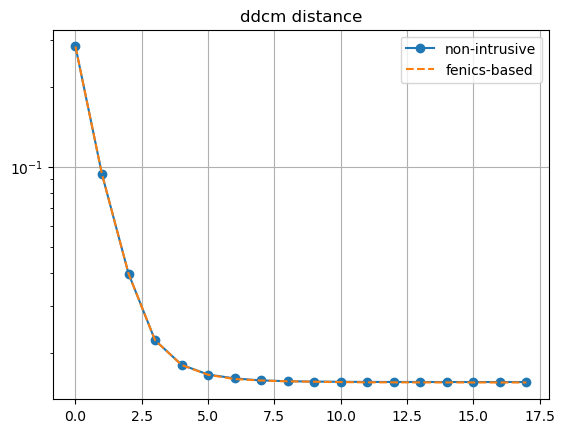

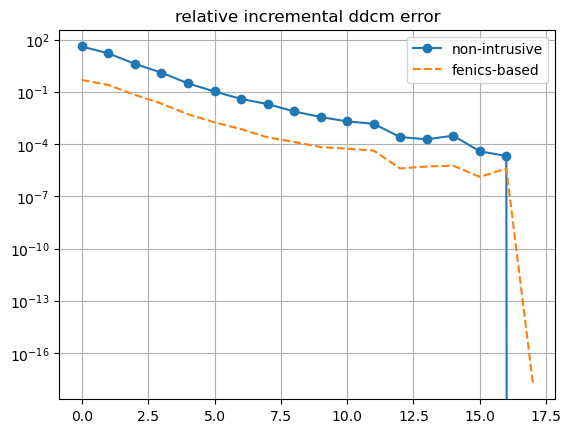

In [18]:
print("error u non-intrusive : ", error_ni)
print("error u fenics-based : ", error_fenics)
print("error non-intrusive agaist fenics-based : ", error_ni_fenics)
print("time ddcm non-intrusive : ", time_ni)
print("time ddcm fenics-based : ", time_fenics)

plt.figure(1)
plt.title("ddcm distance")
plt.plot(solver.hist['distance'], '-o', label = "non-intrusive")
plt.plot(solver_f.hist['distance'], '--', label = "fenics-based")
plt.legend()
plt.yscale('log')
plt.grid()

plt.figure(2)
plt.title("relative incremental ddcm error")
plt.plot(solver.hist['relative_distance'], '-o', label = "non-intrusive")
plt.plot(solver_f.hist['relative_distance'], '--', label = "fenics-based")
plt.legend()
plt.yscale('log')
plt.grid()

pyvista_warp_plot(sol_u_ni, V, gdim = 2, scale_fac = 20.0)